# Insurance Claim Fraud Detection — Model 1: Random Forest

This notebook continues directly from the shared EDA/cleaning work in `Untitled.ipynb`.
It repeats the cleaning + encoding steps (self-contained, so this file can be run on its own),
then trains a **Random Forest** classifier with **Stratified K-Fold cross-validation**
and **hyperparameter tuning** (`RandomizedSearchCV`), and evaluates it with the metrics
required by the project: Precision, Recall, F1, ROC-AUC, and PR-AUC.

Random Forest output from this notebook (`rf_test_proba`) is one of the three signals
that will later be fed into the meta-learner in the Ensemble notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 1. Load data and check the fraud vs legit ratio

Shape: (15420, 33)

Class counts:
 FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Class percentage:
 FraudFound_P
0    94.01
1     5.99
Name: proportion, dtype: float64

=> Highly imbalanced dataset: only 5.99% of claims are fraudulent.


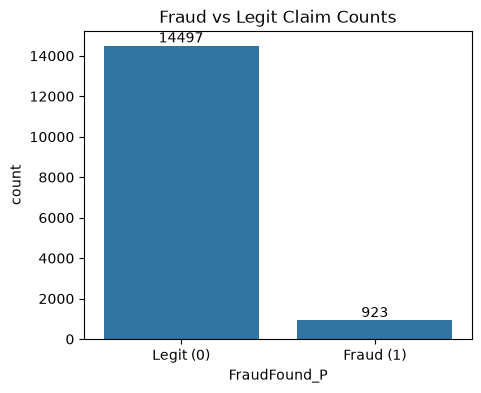

In [3]:
df = pd.read_csv("fraud_oracle.csv")
print("Shape:", df.shape)

counts = df['FraudFound_P'].value_counts()
pct = df['FraudFound_P'].value_counts(normalize=True) * 100
print("\nClass counts:\n", counts)
print("\nClass percentage:\n", pct.round(2))
print(f"\n=> Highly imbalanced dataset: only {pct[1]:.2f}% of claims are fraudulent.")

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='FraudFound_P', data=df, ax=ax)
ax.set_xticklabels(['Legit (0)', 'Fraud (1)'])
ax.set_title('Fraud vs Legit Claim Counts')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()


## 2. Cleaning (same steps as the shared EDA notebook)
- `Age == 0` rows that belong to the `16 to 17` policy-holder age bucket are corrected to `17`.
- The single row with `'0'` placeholders in `DayOfWeekClaimed` / `MonthClaimed` is imputed using
  that same row's `DayOfWeek` / `Month` values (accident day/month), which is a sound proxy since
  the claim was filed very close to the accident.
- `PolicyNumber` is dropped (it's a unique identifier, not a predictive feature).

In [4]:
df.loc[(df['Age'] == 0) & (df['AgeOfPolicyHolder'] == '16 to 17'), 'Age'] = 17
df.loc[df['DayOfWeekClaimed'] == '0', 'DayOfWeekClaimed'] = 'Monday'
df.loc[df['MonthClaimed'] == '0', 'MonthClaimed'] = 'Jul'
df = df.drop(columns=['PolicyNumber'], errors='ignore')

print("Age==0 remaining:", (df['Age']==0).sum())
print("DayOfWeekClaimed=='0' remaining:", (df['DayOfWeekClaimed']=='0').sum())
print("MonthClaimed=='0' remaining:", (df['MonthClaimed']=='0').sum())
print("New shape:", df.shape)


Age==0 remaining: 0
DayOfWeekClaimed=='0' remaining: 0
MonthClaimed=='0' remaining: 0
New shape: (15420, 32)


## 3. Train / test split (stratified, so both sets keep the ~6% fraud ratio)

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['FraudFound_P'])
y = df['FraudFound_P']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train fraud ratio: {:.2f}%".format(y_train.mean()*100))
print("Test  fraud ratio: {:.2f}%".format(y_test.mean()*100))


X_train: (12336, 31)  X_test: (3084, 31)
Train fraud ratio: 5.98%
Test  fraud ratio: 6.00%


## 4. Feature encoding
- **Numeric** columns are standard-scaled.
- **Ordinal** columns (bucketed ranges with a natural order, e.g. `AgeOfVehicle`, `VehiclePrice`)
  are mapped to integers in their real-world order — this preserves the ordering information that
  one-hot encoding would throw away.
- **Nominal/categorical** columns (no inherent order, e.g. `Make`, `PolicyType`) are one-hot encoded.

All encoders are **fit on the training set only** and applied to the test set, to avoid data leakage.

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ['WeekOfMonth','WeekOfMonthClaimed','Age','RepNumber','Deductible','DriverRating','Year']

ordinal_maps = {
    'Days_Policy_Accident': ['none','1 to 7','8 to 15','15 to 30','more than 30'],
    'Days_Policy_Claim':    ['none','8 to 15','15 to 30','more than 30'],
    'PastNumberOfClaims':   ['none','1','2 to 4','more than 4'],
    'AgeOfVehicle':         ['new','2 years','3 years','4 years','5 years','6 years','7 years','more than 7'],
    'AgeOfPolicyHolder':    ['16 to 17','18 to 20','21 to 25','26 to 30','31 to 35','36 to 40','41 to 50','51 to 65','over 65'],
    'NumberOfSuppliments':  ['none','1 to 2','3 to 5','more than 5'],
    'AddressChange_Claim':  ['no change','under 6 months','1 year','2 to 3 years','4 to 8 years'],
    'NumberOfCars':         ['1 vehicle','2 vehicles','3 to 4','5 to 8','more than 8'],
    'VehiclePrice':         ['less than 20000','20000 to 29000','30000 to 39000','40000 to 59000','60000 to 69000','more than 69000'],
}
ordinal_cols = list(ordinal_maps.keys())

categorical_cols = ['Month','DayOfWeek','Make','AccidentArea','DayOfWeekClaimed','MonthClaimed',
                    'Sex','MaritalStatus','Fault','PolicyType','VehicleCategory',
                    'PoliceReportFiled','WitnessPresent','AgentType','BasePolicy']

assert len(numeric_cols) + len(ordinal_cols) + len(categorical_cols) == X_train.shape[1]

def ordinal_encode(data):
    data = data.copy()
    for col, order in ordinal_maps.items():
        data[col] = data[col].map({v: i for i, v in enumerate(order)})
    return data

X_train_ord = ordinal_encode(X_train)
X_test_ord  = ordinal_encode(X_test)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_ord[categorical_cols])
ohe_cols = ohe.get_feature_names_out(categorical_cols)
ohe_train = pd.DataFrame(ohe.transform(X_train_ord[categorical_cols]), columns=ohe_cols, index=X_train_ord.index)
ohe_test  = pd.DataFrame(ohe.transform(X_test_ord[categorical_cols]),  columns=ohe_cols, index=X_test_ord.index)

scaler = StandardScaler()
scaler.fit(X_train_ord[numeric_cols])
num_train = pd.DataFrame(scaler.transform(X_train_ord[numeric_cols]), columns=numeric_cols, index=X_train_ord.index)
num_test  = pd.DataFrame(scaler.transform(X_test_ord[numeric_cols]),  columns=numeric_cols, index=X_test_ord.index)

X_train_final = pd.concat([num_train, X_train_ord[ordinal_cols], ohe_train], axis=1)
X_test_final  = pd.concat([num_test,  X_test_ord[ordinal_cols],  ohe_test],  axis=1)

print("Final encoded shapes -> train:", X_train_final.shape, " test:", X_test_final.shape)


Final encoded shapes -> train: (12336, 104)  test: (3084, 104)


## 5. Random Forest with Stratified K-Fold CV + hyperparameter tuning

We use `class_weight='balanced'` to make the trees pay proportionally more attention to the
minority (fraud) class, and `RandomizedSearchCV` with **Stratified 3-fold CV** (so every fold
keeps the ~6% fraud ratio) scoring on **PR-AUC (average precision)** — the right metric to
optimize for on an imbalanced dataset like this, since ROC-AUC is overly optimistic when
negatives vastly outnumber positives. (3 folds / a modest search grid are used to keep runtime
reasonable — widen `param_distributions` and `n_iter`/`cv` freely if you have more compute.)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_param_dist = {
    'n_estimators': [150, 250, 350],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.5],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)

rf_search.fit(X_train_final, y_train)

print("Best RF hyperparameters:", rf_search.best_params_)
print("Best CV PR-AUC (average_precision):", round(rf_search.best_score_, 4))

best_rf = rf_search.best_estimator_


Best RF hyperparameters: {'n_estimators': 350, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
Best CV PR-AUC (average_precision): 0.2568


## 6. Evaluate on the held-out test set

In [8]:
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve, roc_curve)

rf_test_proba = best_rf.predict_proba(X_test_final)[:, 1]
rf_test_pred  = (rf_test_proba >= 0.5).astype(int)

rf_metrics = {
    'Precision': precision_score(y_test, rf_test_pred),
    'Recall':    recall_score(y_test, rf_test_pred),
    'F1':        f1_score(y_test, rf_test_pred),
    'ROC-AUC':   roc_auc_score(y_test, rf_test_proba),
    'PR-AUC':    average_precision_score(y_test, rf_test_proba),
}
print("=== Random Forest — Test Set Metrics (threshold = 0.5) ===")
for k, v in rf_metrics.items():
    print(f"{k:10}: {v:.4f}")

print("\nClassification report:\n", classification_report(y_test, rf_test_pred, target_names=['Legit','Fraud']))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_test_pred))


=== Random Forest — Test Set Metrics (threshold = 0.5) ===
Precision : 0.2756
Recall    : 0.1892
F1        : 0.2244
ROC-AUC   : 0.8397
PR-AUC    : 0.2490

Classification report:
               precision    recall  f1-score   support

       Legit       0.95      0.97      0.96      2899
       Fraud       0.28      0.19      0.22       185

    accuracy                           0.92      3084
   macro avg       0.61      0.58      0.59      3084
weighted avg       0.91      0.92      0.91      3084

Confusion matrix:
 [[2807   92]
 [ 150   35]]


### 6.1 Threshold tuning

At the default 0.5 cutoff, Random Forest's probabilities are conservative (this is typical with
`class_weight='balanced'` on a ~6%-positive dataset) — precision is high but recall is very low,
meaning most fraud cases slip through undetected. For a fraud-screening use case we usually care
more about **catching fraud (recall)** and are willing to send more claims for human review, so
we search the precision-recall curve for the threshold that maximizes F1, and report metrics
there too. Both operating points (default 0.5 and tuned) are kept so the Ensemble notebook can
compare fairly.

In [9]:
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, rf_test_proba)
f1_arr = (2 * prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-12)
best_idx = np.nanargmax(f1_arr[:-1])  # last point has no matching threshold
best_threshold = thresh_arr[best_idx]

rf_test_pred_tuned = (rf_test_proba >= best_threshold).astype(int)

print(f"Best threshold (max F1): {best_threshold:.3f}")
print(f"Precision @ tuned threshold: {precision_score(y_test, rf_test_pred_tuned):.4f}")
print(f"Recall    @ tuned threshold: {recall_score(y_test, rf_test_pred_tuned):.4f}")
print(f"F1        @ tuned threshold: {f1_score(y_test, rf_test_pred_tuned):.4f}")
print("\nConfusion matrix @ tuned threshold:\n", confusion_matrix(y_test, rf_test_pred_tuned))


Best threshold (max F1): 0.366
Precision @ tuned threshold: 0.2327
Recall    @ tuned threshold: 0.4919
F1        @ tuned threshold: 0.3160

Confusion matrix @ tuned threshold:
 [[2599  300]
 [  94   91]]


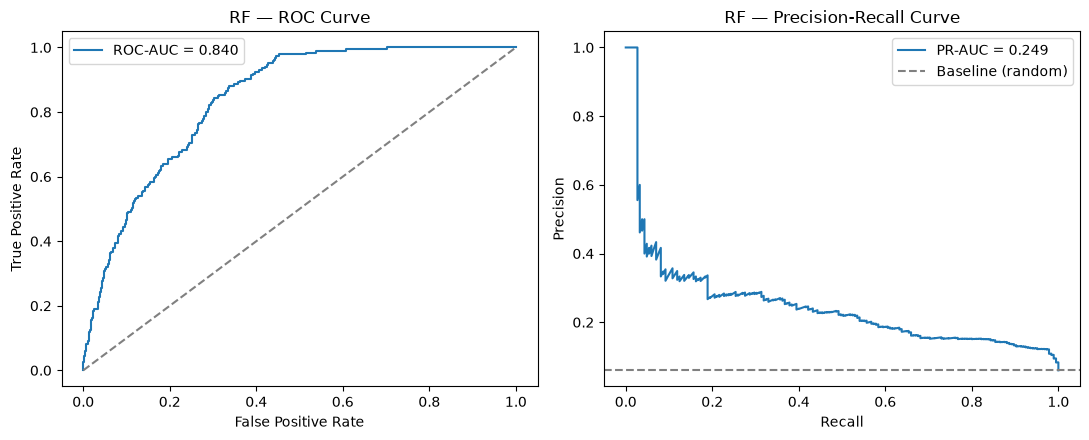

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

fpr, tpr, _ = roc_curve(y_test, rf_test_proba)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {rf_metrics['ROC-AUC']:.3f}")
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('RF — ROC Curve'); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, rf_test_proba)
axes[1].plot(rec, prec, label=f"PR-AUC = {rf_metrics['PR-AUC']:.3f}")
axes[1].axhline(y_test.mean(), color='gray', ls='--', label='Baseline (random)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('RF — Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Feature importance (top 20)

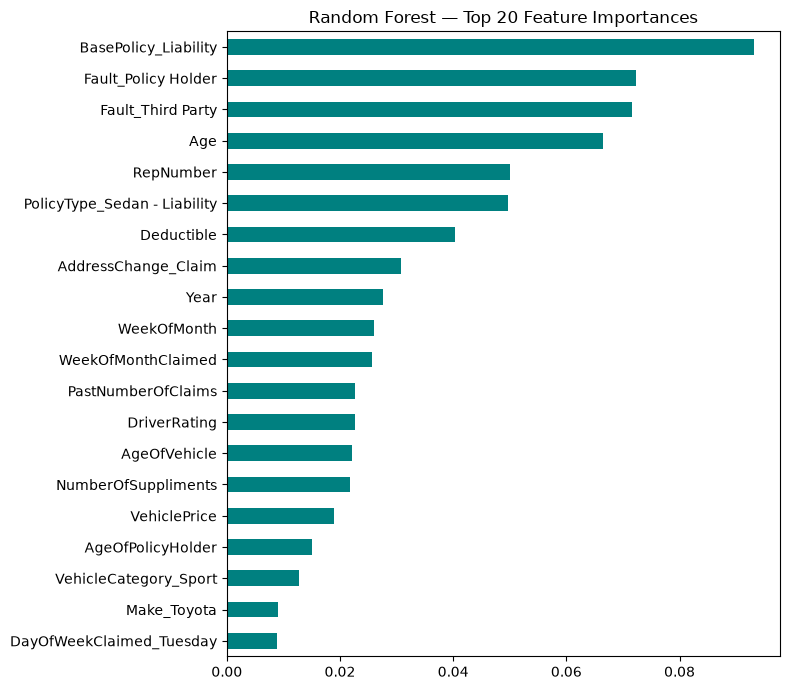

BasePolicy_Liability            0.093099
Fault_Policy Holder             0.072261
Fault_Third Party               0.071557
Age                             0.066495
RepNumber                       0.049964
PolicyType_Sedan - Liability    0.049635
Deductible                      0.040251
AddressChange_Claim             0.030786
Year                            0.027670
WeekOfMonth                     0.026090
WeekOfMonthClaimed              0.025666
PastNumberOfClaims              0.022681
DriverRating                    0.022658
AgeOfVehicle                    0.022043
NumberOfSuppliments             0.021756
VehiclePrice                    0.018911
AgeOfPolicyHolder               0.015077
VehicleCategory_Sport           0.012721
Make_Toyota                     0.009093
DayOfWeekClaimed_Tuesday        0.008906
dtype: float64


In [11]:
importances = pd.Series(best_rf.feature_importances_, index=X_train_final.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8,7))
top20.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print(top20)


## 8. Save the model + test-set predictions

The saved `rf_test_proba.csv` (probabilities per test-set claim) will be reused, alongside
XGBoost's and Isolation Forest's outputs, by the **Ensemble** notebook's meta-learner.

In [12]:
import joblib

joblib.dump(best_rf, "rf_model.pkl")

rf_results = pd.DataFrame({
    'index': X_test_final.index,
    'true_label': y_test.values,
    'rf_proba': rf_test_proba,
    'rf_pred': rf_test_pred,
})
rf_results.to_csv("rf_test_predictions.csv", index=False)
print("Saved rf_model.pkl and rf_test_predictions.csv")
rf_results.head(10)


Saved rf_model.pkl and rf_test_predictions.csv


,index,true_label,rf_proba,rf_pred
0,8922,0,0.002449,0
1,4274,0,0.091559,0
2,3408,0,0.000000,0
3,10675,0,0.191136,0
4,3285,0,0.009900,0
5,11043,0,0.477284,0
6,3495,0,0.000000,0
7,9299,1,0.455730,0
8,10652,0,0.000000,0
9,13126,0,0.000000,0
